<a href="https://colab.research.google.com/github/AlexandreVenturini/mineracao_dados_covid19/blob/main/mineracao_dados_covid19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final — Vacinação contra COVID-19 no Espírito Santo

**Disciplina:** Tópicos Especiais I — TSI  
**Prof.:** Matheus Jagi

---

**Pergunta de pesquisa:** Como se comportou a campanha de vacinação contra COVID-19 no Espírito Santo ao longo do tempo? Existem perfis distintos de vacinados que reflitam a estratégia de priorização adotada?

O objetivo é responder essa pergunta com um pipeline completo: coleta dos dados públicos do OpenDataSUS, limpeza, análise exploratória, mineração com duas técnicas e avaliação dos resultados.

---

### Fonte dos dados

Os dados são provenientes do sistema **OpenDataSUS** (RNDS/Ministério da Saúde), referentes à Parte 1 dos registros de vacinação do Espírito Santo:

> [Campanha Nacional de Vacinação COVID-19 — Dados ES Parte 1](https://dadosabertos.saude.gov.br/dataset/covid-19-vacinacao/resource/5093679f-12c3-4d6b-b7bd-07694de54173)

O arquivo CSV foi baixado do portal OpenDataSUS e armazenado no Google Drive do pesquisador. O carregamento é feito via montagem do Drive no Colab (`drive.mount`), lendo o arquivo salvo em `/content/drive/MyDrive/vacinacao_covid.csv`.


## 1. Bibliotecas


In [ ]:
!pip install geopandas -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
import unicodedata
import requests
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

print('Bibliotecas importadas com sucesso!')


Mounted at /content/drive
Bibliotecas importadas com sucesso!


## 2. Coleta e Carregamento dos Dados

O dataset é o arquivo **Dados ES - Parte 1** do OpenDataSUS, que contém os registros individuais de vacinação contra COVID-19 no Espírito Santo desde o início da campanha em 2021. Os dados são anonimizados e de acesso público.

Por limitação de memória do Colab, o carregamento foi limitado a 2 milhões de registros — suficiente para capturar todo o período principal da campanha estadual.

As colunas selecionadas foram as relevantes para a análise: identificador do paciente, idade, sexo biológico, fabricante, data de aplicação, município e descrição da dose.


In [ ]:
CAMINHO_ARQUIVO = '/content/drive/MyDrive/vacinacao_covid.csv'

COLUNAS = [
    'paciente_id', 'paciente_idade', 'paciente_enumSexoBiologico',
    'vacina_nome', 'vacina_dataAplicacao', 'vacina_fabricante_nome',
    'estabelecimento_municipio_nome', 'vacina_descricao_dose'
]

TIPOS = {
    'paciente_idade': 'float32',
    'paciente_enumSexoBiologico': 'category',
    'vacina_fabricante_nome': 'category'
}

def carregar_dados():
    df = pd.read_csv(
        CAMINHO_ARQUIVO,
        sep=';',
        usecols=COLUNAS,
        dtype=TIPOS,
        nrows=2_000_000
    )
    return df

df_bruto = carregar_dados()

print(f'Dataset carregado com {df_bruto.shape[0]:,} linhas e {df_bruto.shape[1]} colunas.')


Dataset carregado com 2,000,000 linhas e 8 colunas.


### Verificação inicial

In [ ]:
print('Tipos de variáveis:')
print(df_bruto.dtypes)

print('\nValores ausentes por coluna:')
print(df_bruto.isnull().sum())

print(f'\nRegistros duplicados: {df_bruto.duplicated().sum()}')

Tipos de variáveis:
paciente_id                         object
paciente_idade                     float32
paciente_enumSexoBiologico        category
estabelecimento_municipio_nome      object
vacina_fabricante_nome            category
vacina_dataAplicacao                object
vacina_descricao_dose               object
vacina_nome                         object
dtype: object

Valores ausentes por coluna:
paciente_id                        8
paciente_idade                     8
paciente_enumSexoBiologico         8
estabelecimento_municipio_nome     0
vacina_fabricante_nome             0
vacina_dataAplicacao               0
vacina_descricao_dose              0
vacina_nome                       26
dtype: int64

Registros duplicados: 1304


## 3. Limpeza e Preparação

Antes de qualquer análise foi preciso tratar alguns problemas encontrados no dataset:
registros duplicados, valores ausentes nas colunas principais, datas mal formatadas e idades fora do intervalo plausível.
Também foi feita a padronização dos nomes de municípios (tudo em maiúsculas) e correção de caracteres especiais nos nomes dos fabricantes — provavelmente um problema de encoding na exportação original.

Foram criadas colunas auxiliares de data (mês, ano, ano-mês) que serão usadas nas etapas de mineração.

Dois tratamentos adicionais foram aplicados: o filtro de data passou a usar 17/01/2021 como corte (início oficial da campanha nacional de vacinação contra Covid-19, conforme Portaria GM/MS nº 69/2021), em vez de um filtro genérico por ano. Além disso, o fabricante foi consolidado numa coluna `vacina_fabricante_grupo`: "ASTRAZENECA" e "ASTRAZENECA/FIOCRUZ" são o mesmo imunizante (nome oficial registrado na Anvisa, produzido no Brasil pela Fiocruz), assim como "BUTANTAN" e "SINOVAC/BUTANTAN" (mesma vacina CoronaVac, produzida/distribuída pelo Instituto Butantan) — a variação de nome reflete inconsistência de registro entre postos de vacinação, não produtos diferentes. A coluna original `vacina_fabricante_nome` foi mantida intacta para auditoria.


In [ ]:
def processar_dados(df):
    df = df.drop_duplicates()

    df = df.dropna(subset=['paciente_idade', 'vacina_nome'])

    df['vacina_dataAplicacao'] = pd.to_datetime(
        df['vacina_dataAplicacao'], errors='coerce'
    )
    df = df.dropna(subset=['vacina_dataAplicacao'])
    df = df[df['vacina_dataAplicacao'] >= '2021-01-17']

    df['estabelecimento_municipio_nome'] = (
        df['estabelecimento_municipio_nome'].str.upper().str.strip()
    )

    df['vacina_fabricante_nome'] = (
        df['vacina_fabricante_nome']
        .astype(str)
        .replace({
            'PFIZER - PEDI?TRICA': 'PFIZER - PEDIÁTRICA',
            'Pendente Identifica??o': 'Pendente Identificação'
        })
    )

    grupo_fabricante = {
        'ASTRAZENECA': 'ASTRAZENECA/FIOCRUZ',
        'ASTRAZENECA/FIOCRUZ': 'ASTRAZENECA/FIOCRUZ',
        'BUTANTAN': 'SINOVAC/BUTANTAN',
        'SINOVAC/BUTANTAN': 'SINOVAC/BUTANTAN',
    }
    df['vacina_fabricante_grupo'] = (
        df['vacina_fabricante_nome'].map(grupo_fabricante)
        .fillna(df['vacina_fabricante_nome'])
    )

    df = df[(df['paciente_idade'] >= 0) & (df['paciente_idade'] <= 115)]

    df['mes_aplicacao']  = df['vacina_dataAplicacao'].dt.month
    df['ano_aplicacao']  = df['vacina_dataAplicacao'].dt.year
    df['ano_mes']        = df['vacina_dataAplicacao'].dt.to_period('M')

    return df

df_limpo = processar_dados(df_bruto)

print(f'Limpeza concluída! Total de registros após tratamento: {df_limpo.shape[0]:,}')


Limpeza concluída! Total de registros após tratamento: 1,998,614


## 4. Análise Exploratória

Com os dados limpos, o objetivo aqui é entender o perfil geral dos vacinados e identificar padrões antes de partir para as técnicas de mineração.

### 4.1 Estatísticas descritivas — Idade dos pacientes

In [ ]:
idades = df_limpo['paciente_idade'].dropna()
idades = idades[(idades >= 0) & (idades <= 120)]

print(f'Total de registros válidos: {len(idades):,}')
print(f'Média    : {idades.mean():.2f} anos')
print(f'Mediana  : {idades.median():.0f} anos')
print(f'Moda     : {idades.mode()[0]:.0f} anos')
print(f'Desvio   : {idades.std():.2f}')
print(f'Variância: {idades.var():.2f}')
print(f'Mínima   : {idades.min():.0f} anos')
print(f'Máxima   : {idades.max():.0f} anos')
print(f'Amplitude: {idades.max() - idades.min():.0f} anos')


Total de registros válidos: 1,998,614
Média    : 42.17 anos
Mediana  : 42 anos
Moda     : 40 anos
Desvio   : 21.27
Variância: 452.41
Mínima   : 0 anos
Máxima   : 115 anos
Amplitude: 115 anos


### 4.2 Visualizações

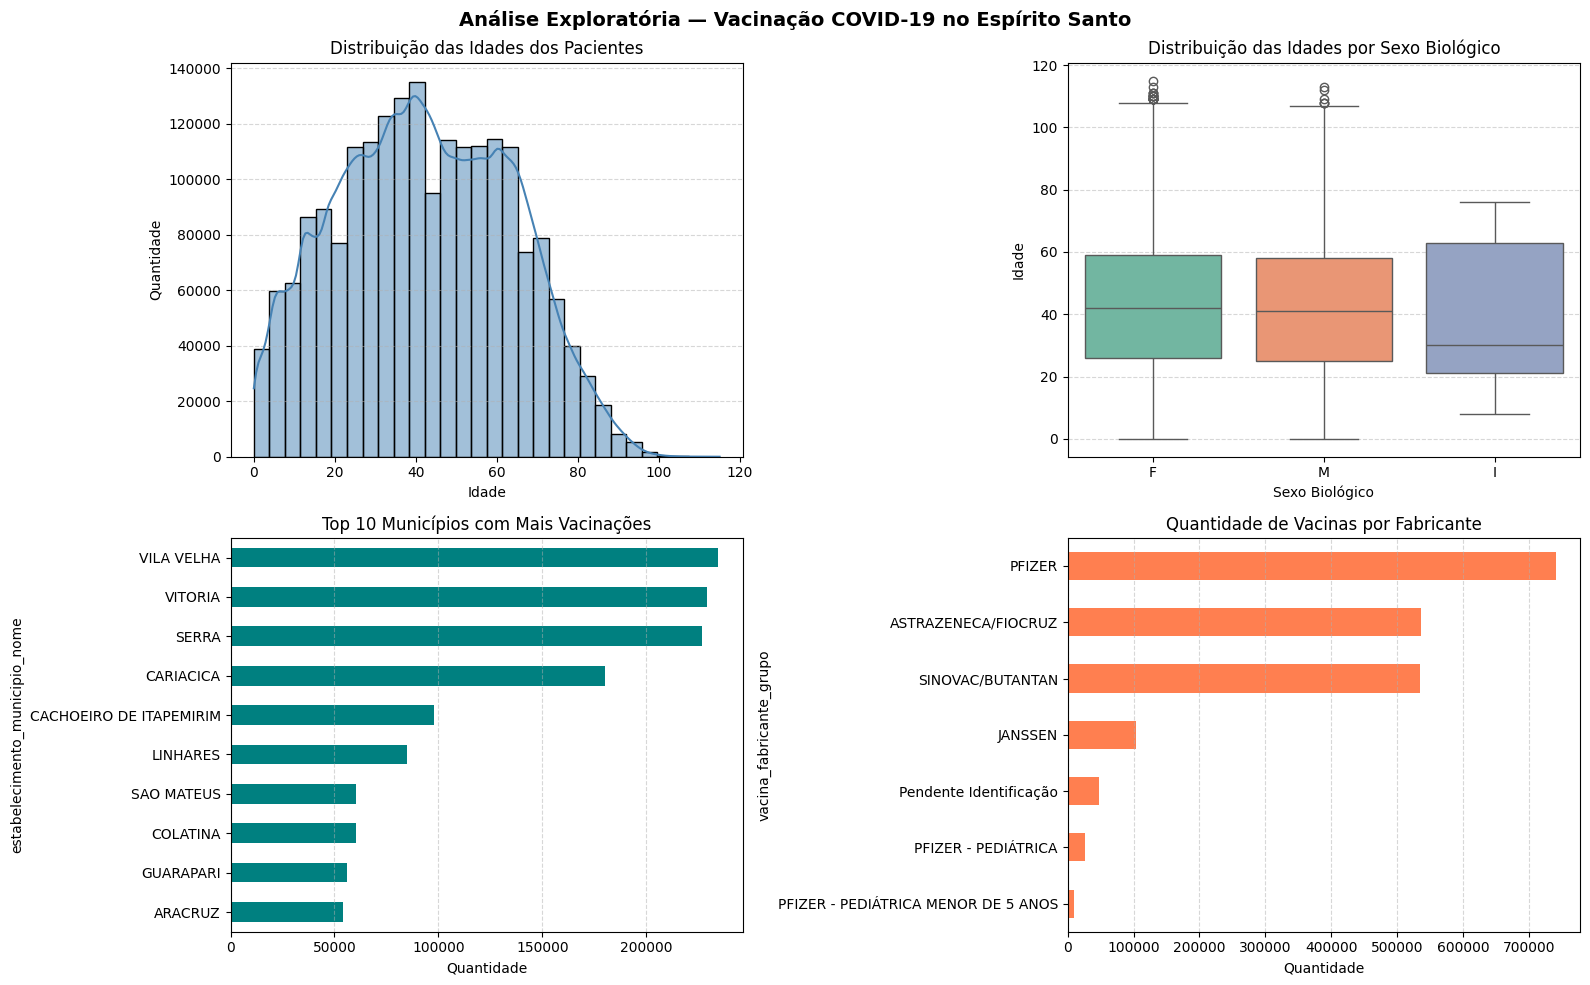

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análise Exploratória — Vacinação COVID-19 no Espírito Santo', fontsize=14, fontweight='bold')

sns.histplot(idades, bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribuição das Idades dos Pacientes')
axes[0, 0].set_xlabel('Idade')
axes[0, 0].set_ylabel('Quantidade')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df_limpo, x='paciente_enumSexoBiologico', y='paciente_idade',
            ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Distribuição das Idades por Sexo Biológico')
axes[0, 1].set_xlabel('Sexo Biológico')
axes[0, 1].set_ylabel('Idade')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

top_municipios = df_limpo['estabelecimento_municipio_nome'].value_counts().head(10)
top_municipios.sort_values().plot(kind='barh', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Top 10 Municípios com Mais Vacinações')
axes[1, 0].set_xlabel('Quantidade')
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.5)

fab_counts = df_limpo['vacina_fabricante_grupo'].value_counts().head(8)
fab_counts.sort_values().plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Quantidade de Vacinas por Fabricante')
axes[1, 1].set_xlabel('Quantidade')
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


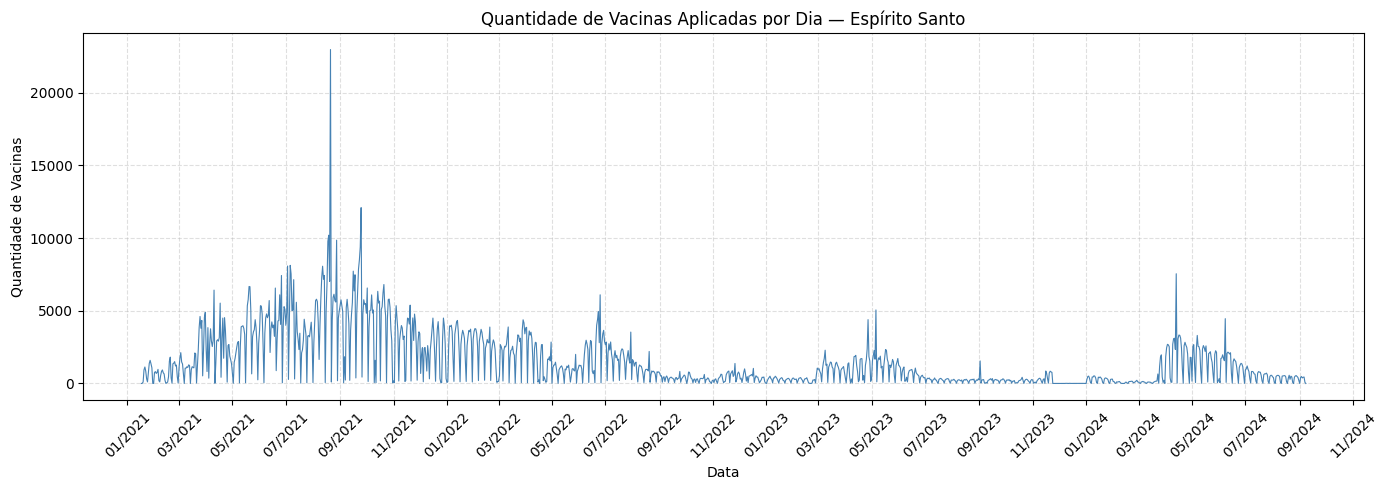

In [ ]:
vacinas_por_dia = df_limpo.groupby('vacina_dataAplicacao').size()

plt.figure(figsize=(14, 5))
plt.plot(vacinas_por_dia.index, vacinas_por_dia.values, color='steelblue', linewidth=0.8)
plt.title('Quantidade de Vacinas Aplicadas por Dia — Espírito Santo')
plt.xlabel('Data')
plt.ylabel('Quantidade de Vacinas')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 4.3 Outliers de idade — método IQR

In [ ]:
Q1  = idades.quantile(0.25)
Q3  = idades.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = idades[(idades < limite_inferior) | (idades > limite_superior)]

print(f'Q1: {Q1:.1f}  |  Q3: {Q3:.1f}  |  IQR: {IQR:.1f}')
print(f'Limite inferior: {limite_inferior:.1f}  |  Limite superior: {limite_superior:.1f}')
print(f'Outliers detectados: {len(outliers):,}')


Q1: 26.0  |  Q3: 59.0  |  IQR: 33.0
Limite inferior: -23.5  |  Limite superior: 108.5
Outliers detectados: 23


### 4.4 KPIs da campanha

In [ ]:
total_vacinas    = len(df_limpo)
media_idade      = df_limpo['paciente_idade'].mean()
fabricante_top   = df_limpo['vacina_fabricante_grupo'].value_counts().idxmax()
mes_pico         = df_limpo['mes_aplicacao'].value_counts().idxmax()
municipio_top    = df_limpo['estabelecimento_municipio_nome'].value_counts().idxmax()
nomes_meses      = {1:'Janeiro',2:'Fevereiro',3:'Março',4:'Abril',5:'Maio',6:'Junho',
                    7:'Julho',8:'Agosto',9:'Setembro',10:'Outubro',11:'Novembro',12:'Dezembro'}

print(f'Total de vacinas aplicadas:  {total_vacinas:,}')
print(f'Média de idade dos pacientes: {media_idade:.1f} anos')
print(f'Fabricante mais utilizado:    {fabricante_top}')
print(f'Mês com mais vacinações:      {nomes_meses[mes_pico]}')
print(f'Município com mais registros: {municipio_top}')


Total de vacinas aplicadas:  1,998,614
Média de idade dos pacientes: 42.2 anos
Fabricante mais utilizado:    PFIZER
Mês com mais vacinações:      Junho
Município com mais registros: VILA VELHA


### 4.5 Distribuição Geográfica — Mapa de Vacinações por Município

Além do ranking em barras (seção 4.2), é útil visualizar a distribuição espacial das vacinações no mapa do Espírito Santo. Isso ajuda a entender melhor a escala entre municípios grandes e pequenos — por exemplo, Santa Teresa não aparece no Top 10 simplesmente por ter uma população bem menor que polos como Vila Velha ou Vitória, não por algum problema nos dados.

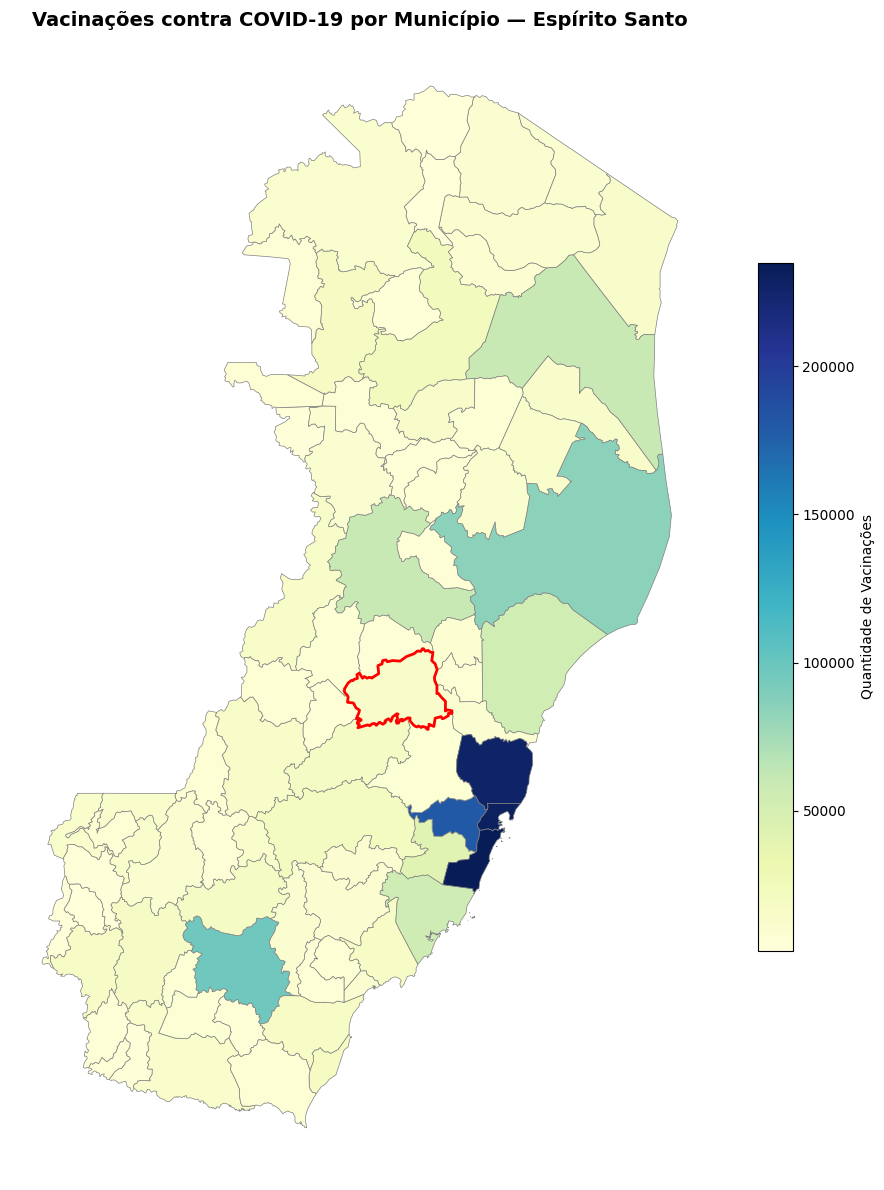

In [ ]:
def normalizar_nome(nome):
    nome = unicodedata.normalize('NFKD', nome).encode('ASCII', 'ignore').decode('utf-8')
    return nome.upper().strip()

url_geojson = 'https://raw.githubusercontent.com/tbrugz/geodata-br/master/geojson/geojs-32-mun.json'
geojson_data = requests.get(url_geojson).json()
gdf_es = gpd.GeoDataFrame.from_features(geojson_data['features'], crs='EPSG:4326')
gdf_es['municipio_norm'] = gdf_es['name'].apply(normalizar_nome)

vacinas_municipio = (
    df_limpo
    .groupby('estabelecimento_municipio_nome')
    .size()
    .reset_index(name='quantidade')
)
vacinas_municipio['municipio_norm'] = vacinas_municipio['estabelecimento_municipio_nome'].apply(normalizar_nome)

gdf_merged = gdf_es.merge(
    vacinas_municipio[['municipio_norm', 'quantidade']],
    on='municipio_norm',
    how='left'
)
gdf_merged['quantidade'] = gdf_merged['quantidade'].fillna(0)

nao_encontrados = set(vacinas_municipio['municipio_norm']) - set(gdf_es['municipio_norm'])
if nao_encontrados:
    print('Atenção, municípios sem correspondência no geojson:', nao_encontrados)

fig, ax = plt.subplots(1, 1, figsize=(10, 12))

gdf_merged.plot(
    column='quantidade',
    cmap='YlGnBu',
    linewidth=0.5,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': 'Quantidade de Vacinações', 'shrink': 0.6},
    ax=ax
)

santa_teresa = gdf_merged[gdf_merged['municipio_norm'] == 'SANTA TERESA']
santa_teresa.boundary.plot(ax=ax, color='red', linewidth=2)

ax.set_title('Vacinações contra COVID-19 por Município — Espírito Santo', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

O mapa confirma o que os dados de população já sugeriam: a concentração de vacinações segue a concentração populacional do estado, com destaque para a Região Metropolitana (Vila Velha, Vitória, Serra, Cariacica) em tons mais escuros. Municípios menores do interior, como Santa Teresa (contorno em vermelho), aparecem em tons mais claros — não porque a cobertura vacinal lá tenha sido pior, mas porque o volume absoluto de habitantes é bem menor.

## 5. Mineração de Dados

Foram aplicadas duas técnicas de mineração, escolhidas com base na natureza do dataset — dados numérico-estruturados com forte componente temporal, sem campos de texto livre:

- **K-Means Clustering:** segmentar perfis de vacinados por idade e período de vacinação
- **Análise de tendência + detecção de outliers temporais:** entender a evolução da campanha e identificar dias com comportamento fora do padrão

### 5.1 Clustering com K-Means

A pergunta que guia esta etapa é: existem grupos naturais de vacinados no ES com base na idade e no momento em que foram vacinados? Esses grupos refletem a estratégia de priorização da campanha?

O K-Means é um algoritmo de aprendizado não supervisionado — ele agrupa os registros sem precisar de rótulos prévios, buscando minimizar a distância interna de cada grupo.

#### Preparação das features

As features utilizadas foram `paciente_idade` e uma variável chamada `mes_continuo`, que representa a posição absoluta do mês na linha do tempo (ex: janeiro/2021 = 1, janeiro/2022 = 13). Isso permite que o algoritmo capture tanto o perfil etário quanto o timing da vacinação.

A normalização com Z-Score é necessária para que idade e mês tenham o mesmo peso no cálculo de distância — sem isso, a variável de maior escala dominaria o clustering.

In [ ]:
np.random.seed(42)
df_amostra = df_limpo[['paciente_idade', 'mes_aplicacao', 'ano_aplicacao']].dropna()
df_amostra = df_amostra.sample(n=min(100000, len(df_amostra)), random_state=42)

df_amostra = df_amostra.copy()
df_amostra['mes_continuo'] = (df_amostra['ano_aplicacao'] - 2021) * 12 + df_amostra['mes_aplicacao']

features = df_amostra[['paciente_idade', 'mes_continuo']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f'Amostras para clustering: {features_scaled.shape[0]:,}')
print(f'Features utilizadas     : {list(features.columns)}')
print('\nEstatísticas após normalização (deve ter média ≈ 0 e desvio ≈ 1):')
print(pd.DataFrame(features_scaled, columns=features.columns).describe().round(3))

Amostras para clustering: 100,000
Features utilizadas     : ['paciente_idade', 'mes_continuo']

Estatísticas após normalização (deve ter média ≈ 0 e desvio ≈ 1):
       paciente_idade  mes_continuo
count      100000.000    100000.000
mean           -0.000         0.000
std             1.000         1.000
min            -1.980        -1.268
25%            -0.758        -0.642
50%            -0.007        -0.374
75%             0.792         0.341
max             3.281         2.667


#### Método do cotovelo — escolha do K

O método do cotovelo testa o K-Means para diferentes valores de K e registra a inércia (soma das distâncias ao centroide). O K ideal fica onde a curva para de cair de forma acentuada.
O Silhouette Score complementa essa análise: valores mais altos indicam clusters mais bem separados.

K=2 | Inércia: 121,202 | Silhouette: 0.4797
K=3 | Inércia: 70,933 | Silhouette: 0.4336
K=4 | Inércia: 49,245 | Silhouette: 0.4560
K=5 | Inércia: 38,031 | Silhouette: 0.3984
K=6 | Inércia: 32,450 | Silhouette: 0.4094
K=7 | Inércia: 28,404 | Silhouette: 0.3807
K=8 | Inércia: 24,627 | Silhouette: 0.3810


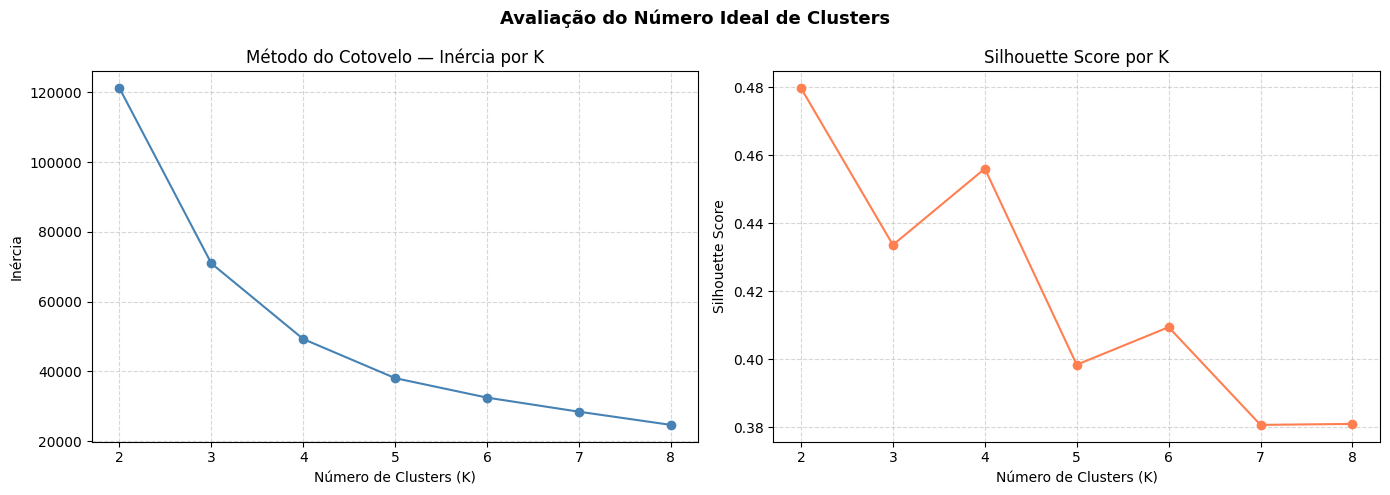

In [ ]:
inercias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(features_scaled)
    inercias.append(kmeans_temp.inertia_)
    silhouettes.append(silhouette_score(features_scaled, labels_temp, sample_size=10000, random_state=42))
    print(f'K={k} | Inércia: {kmeans_temp.inertia_:,.0f} | Silhouette: {silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inercias, 'o-', color='steelblue')
axes[0].set_title('Método do Cotovelo — Inércia por K')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(linestyle='--', alpha=0.5)

axes[1].plot(list(K_range), silhouettes, 'o-', color='coral')
axes[1].set_title('Silhouette Score por K')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(linestyle='--', alpha=0.5)

plt.suptitle('Avaliação do Número Ideal de Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Aplicação do K-Means

Com base nos gráficos acima, define-se o K. Ajuste a variável `K_ESCOLHIDO` conforme o cotovelo observado.

In [ ]:
K_ESCOLHIDO = 4

kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
df_amostra['cluster'] = kmeans.fit_predict(features_scaled)

sil_score = silhouette_score(features_scaled, df_amostra['cluster'],
                              sample_size=10000, random_state=42)

print(f'K-Means aplicado com K = {K_ESCOLHIDO}')
print(f'Silhouette Score final : {sil_score:.4f}')
print(f'Inércia final          : {kmeans.inertia_:,.0f}')
print()
print('Distribuição dos registros por cluster:')
print(df_amostra['cluster'].value_counts().sort_index())

K-Means aplicado com K = 4
Silhouette Score final : 0.4560
Inércia final          : 49,245

Distribuição dos registros por cluster:
cluster
0    36944
1     9637
2    42775
3    10644
Name: count, dtype: int64


#### Perfil e visualização dos clusters

In [ ]:
perfil = df_amostra.groupby('cluster')[['paciente_idade', 'mes_continuo']].mean().round(1)
perfil.columns = ['Idade Média', 'Mês Contínuo Médio']
perfil['Qtd Registros'] = df_amostra['cluster'].value_counts().sort_index().values
print(perfil)


         Idade Média  Mês Contínuo Médio  Qtd Registros
cluster                                                
0          60.500000                 9.0          36944
1          15.900000                35.3           9637
2          27.400000                11.3          42775
3          61.700001                34.3          10644


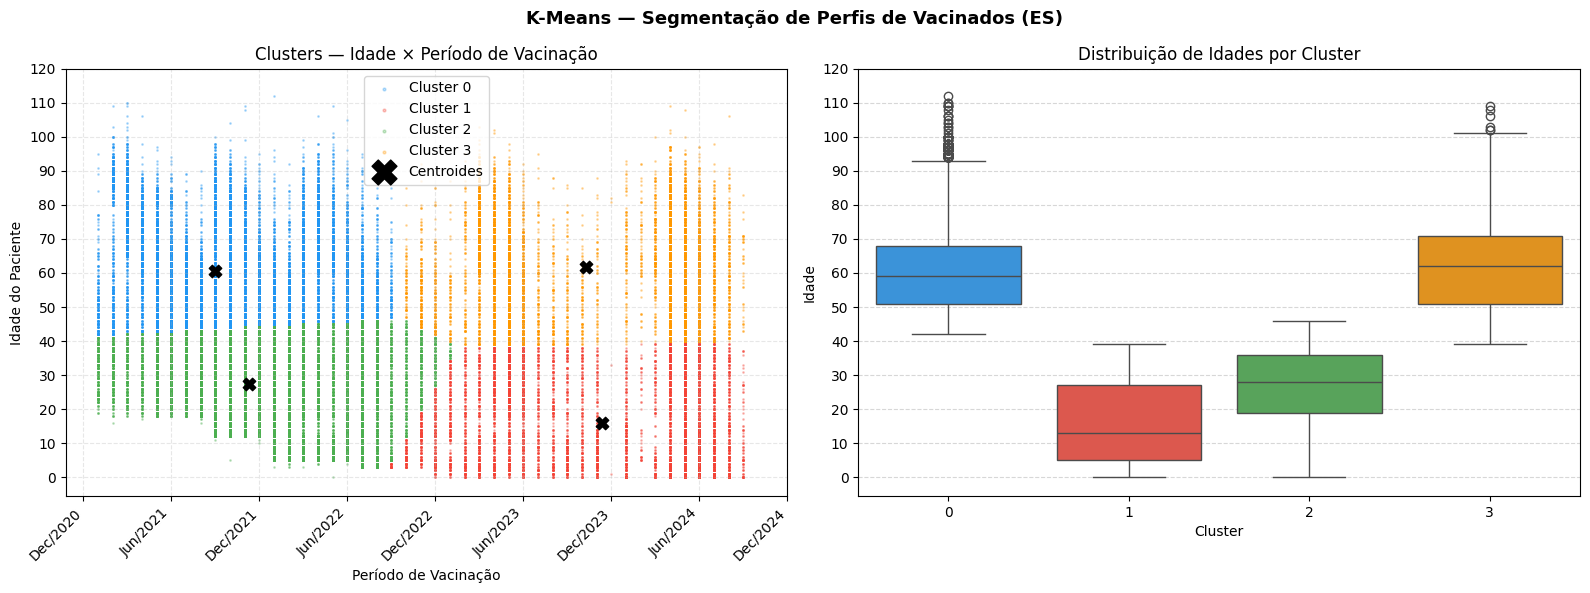

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cores = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

for c in range(K_ESCOLHIDO):
    mask = df_amostra['cluster'] == c
    axes[0].scatter(
        df_amostra.loc[mask, 'mes_continuo'],
        df_amostra.loc[mask, 'paciente_idade'],
        s=1, alpha=0.3, color=cores[c], label=f'Cluster {c}'
    )

centroides_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(
    centroides_orig[:, 1], centroides_orig[:, 0],
    s=80, c='black', marker='X', zorder=5, label='Centroides'
)

base_data = pd.Timestamp('2020-12-01')
mc_min = int(df_amostra['mes_continuo'].min())
mc_max = int(df_amostra['mes_continuo'].max())
ticks_mc = list(range(mc_min - (mc_min % 6), mc_max + 6, 6))
labels_data = [(base_data + pd.DateOffset(months=m)).strftime('%b/%Y') for m in ticks_mc]
axes[0].set_xticks(ticks_mc)
axes[0].set_xticklabels(labels_data, rotation=45, ha='right')

axes[0].set_yticks(range(0, 121, 10))

axes[0].set_title('Clusters — Idade × Período de Vacinação')
axes[0].set_xlabel('Período de Vacinação')
axes[0].set_ylabel('Idade do Paciente')
axes[0].legend(markerscale=2)
axes[0].grid(linestyle='--', alpha=0.3)

sns.boxplot(
    data=df_amostra, x='cluster', y='paciente_idade',
    palette=cores[:K_ESCOLHIDO], ax=axes[1]
)
axes[1].set_yticks(range(0, 121, 10))
axes[1].set_title('Distribuição de Idades por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Idade')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('K-Means — Segmentação de Perfis de Vacinados (ES)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### Interpretação

Olhando o perfil de cada cluster (idade média × período médio), o padrão não é uma simples relação decrescente entre tempo e idade — existem **dois grupos de idosos** e **dois grupos mais jovens**, separados por momentos distintos da campanha:

- **Cluster com idade ≈ 61 anos, concentrado por volta de ago/2021** — corresponde ao grupo prioritário inicial (idosos e profissionais de saúde), vacinado logo no começo da campanha, como esperado pela estratégia de priorização por risco.
- **Cluster com idade ≈ 28 anos, concentrado por volta de out/2021** — reflete a abertura da campanha para a população adulta geral, alguns meses depois do grupo prioritário.
- **Cluster com idade ≈ 61 anos, concentrado por volta de out/2023** — um segundo grupo de idosos, mas bem mais tarde. Não faz parte da fase de priorização inicial: é mais coerente com **doses de reforço (booster)**, que voltam a ser aplicadas recorrentemente nesse público em campanhas anuais.
- **Cluster com idade ≈ 16 anos, concentrado por volta de nov/2023** — grupo mais jovem vacinado tardiamente, possivelmente ligado à ampliação da elegibilidade para adolescentes/crianças ou também a doses de reforço nessa faixa etária.

Ou seja, o K-Means não encontrou uma tendência linear simples, mas sim **dois ciclos** de vacinação por idade: o ciclo inicial da campanha (idosos primeiro, depois adultos) e um ciclo posterior de reforços (que volta a priorizar idosos, com os mais jovens chegando depois). Isso é coerente com o que se sabe sobre a campanha nacional: depois da fase de imunização inicial em massa, as doses de reforço passaram a ser aplicadas de forma escalonada, repetindo a lógica de priorização por risco.

O Silhouette Score (~0,45) indica separação razoável entre os clusters — não é uma divisão perfeita, mas captura bem esses dois ciclos etários distintos.


### 5.2 Análise de Tendência e Outliers Temporais

A segunda técnica explora a série temporal de vacinações diárias com dois objetivos: entender como a campanha evoluiu ao longo do tempo e identificar dias com comportamento fora do padrão.

Para detectar os outliers, foi utilizado o método IQR — o mesmo aplicado anteriormente nas idades dos pacientes. A lógica é idêntica: dias com volume de vacinação abaixo de Q1 − 1,5×IQR ou acima de Q3 + 1,5×IQR são considerados anômalos.


#### Construção e suavização da série

In [ ]:
serie_diaria = (
    df_limpo
    .groupby('vacina_dataAplicacao')
    .size()
    .rename('vacinas_dia')
    .sort_index()
)

idx_completo = pd.date_range(serie_diaria.index.min(), serie_diaria.index.max(), freq='D')
serie_diaria = serie_diaria.reindex(idx_completo, fill_value=0)

serie_diaria_df = serie_diaria.to_frame()
serie_diaria_df['media_movel_7d'] = serie_diaria_df['vacinas_dia'].rolling(window=7, center=True).mean()

serie_diaria_df['tendencia_30d'] = serie_diaria_df['vacinas_dia'].rolling(window=30, center=True).mean()

print(f'Série temporal de {serie_diaria_df.index.min().date()} a {serie_diaria_df.index.max().date()}')
print(f'Total de dias: {len(serie_diaria_df)}')
print(f'\nEstatísticas da série diária:')
print(serie_diaria_df['vacinas_dia'].describe().round(1))

Série temporal de 2021-01-17 a 2024-09-08
Total de dias: 1331

Estatísticas da série diária:
count     1331.0
mean      1501.6
std       1886.8
min          0.0
25%        197.0
50%        671.0
75%       2376.0
max      22976.0
Name: vacinas_dia, dtype: float64


#### Identificação de outliers temporais — método IQR

O mesmo método usado para detectar idades fora do padrão pode ser aplicado à série temporal: calcula-se o IQR das vacinações diárias e qualquer dia que caia abaixo de Q1 − 1,5×IQR ou acima de Q3 + 1,5×IQR é marcado como outlier.

Esse método é direto e está dentro do que foi estudado nas aulas — sem precisar de decomposição ou normalização adicional.


In [ ]:
Q1_serie  = serie_diaria_df['vacinas_dia'].quantile(0.25)
Q3_serie  = serie_diaria_df['vacinas_dia'].quantile(0.75)
IQR_serie = Q3_serie - Q1_serie

lim_inf_serie = Q1_serie - 1.5 * IQR_serie
lim_sup_serie = Q3_serie + 1.5 * IQR_serie

df_outlier = serie_diaria_df.copy()
df_outlier['outlier'] = (
    (df_outlier['vacinas_dia'] < lim_inf_serie) |
    (df_outlier['vacinas_dia'] > lim_sup_serie)
)
df_outlier['tipo_outlier'] = 'Normal'
df_outlier.loc[df_outlier['vacinas_dia'] > lim_sup_serie, 'tipo_outlier'] = 'Pico'
df_outlier.loc[df_outlier['vacinas_dia'] < lim_inf_serie, 'tipo_outlier'] = 'Queda'

print(f'Q1: {Q1_serie:.0f}  |  Q3: {Q3_serie:.0f}  |  IQR: {IQR_serie:.0f}')
print(f'Limite inferior: {lim_inf_serie:.0f}  |  Limite superior: {lim_sup_serie:.0f}')
print(f'Outliers detectados: {df_outlier["outlier"].sum()} dias')
print(f'  Picos : {(df_outlier["tipo_outlier"] == "Pico").sum()}')
print(f'  Quedas: {(df_outlier["tipo_outlier"] == "Queda").sum()}')


Q1: 197  |  Q3: 2376  |  IQR: 2179
Limite inferior: -3072  |  Limite superior: 5644
Outliers detectados: 49 dias
  Picos : 49
  Quedas: 0


#### Visualização dos outliers na série


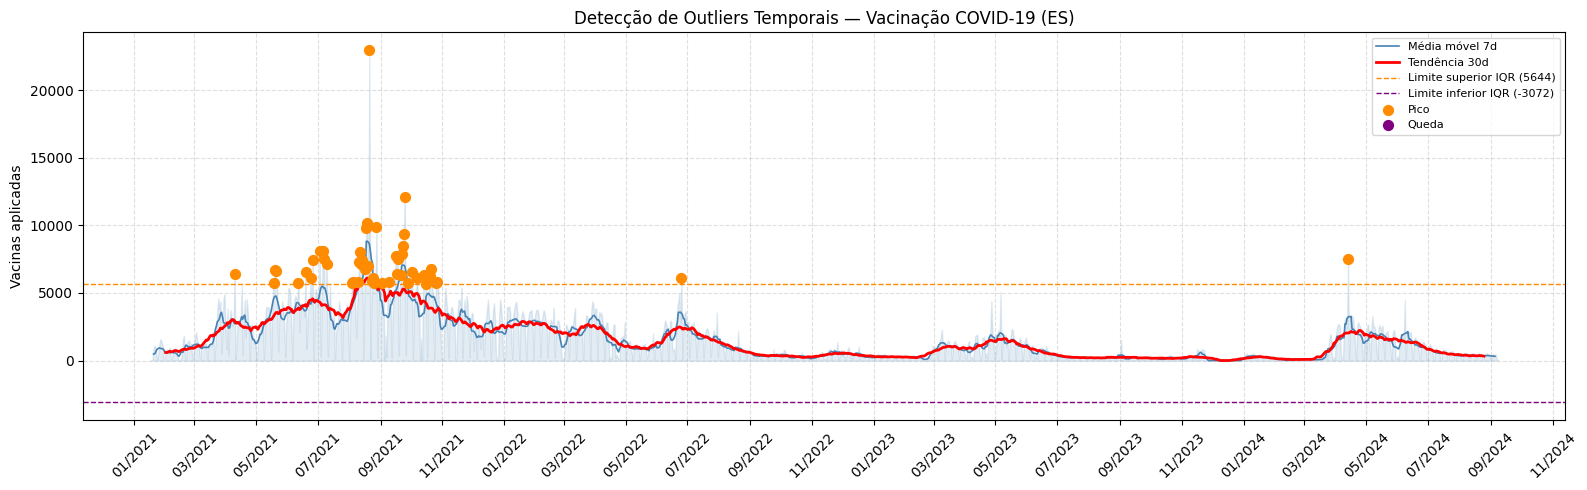

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

picos  = df_outlier[df_outlier['tipo_outlier'] == 'Pico']
quedas = df_outlier[df_outlier['tipo_outlier'] == 'Queda']

ax.fill_between(df_outlier.index, df_outlier['vacinas_dia'], alpha=0.15, color='steelblue')
ax.plot(df_outlier.index, df_outlier['media_movel_7d'], color='steelblue', linewidth=1.2, label='Média móvel 7d')
ax.plot(df_outlier.index, df_outlier['tendencia_30d'], color='red', linewidth=2, label='Tendência 30d')
ax.axhline(lim_sup_serie, color='darkorange', linestyle='--', linewidth=1, label=f'Limite superior IQR ({lim_sup_serie:.0f})')
ax.axhline(lim_inf_serie, color='purple', linestyle='--', linewidth=1, label=f'Limite inferior IQR ({lim_inf_serie:.0f})')
ax.scatter(picos.index, picos['vacinas_dia'], color='darkorange', s=50, zorder=5, label='Pico')
ax.scatter(quedas.index, quedas['vacinas_dia'], color='purple', s=50, zorder=5, label='Queda')
ax.set_title('Detecção de Outliers Temporais — Vacinação COVID-19 (ES)')
ax.set_ylabel('Vacinas aplicadas')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
top_anomalos = (
    df_outlier[df_outlier['outlier']]
    .sort_values('vacinas_dia', ascending=False)
    .head(10)
    [['vacinas_dia', 'media_movel_7d', 'tipo_outlier']]
)
top_anomalos.columns = ['Vacinas no Dia', 'Média Móvel 7d', 'Tipo']
top_anomalos['Média Móvel 7d'] = top_anomalos['Média Móvel 7d'].round(0)
top_anomalos


,Vacinas no Dia,Média Móvel 7d,Tipo
2021-08-21,22976,8627.0,Pico
2021-09-25,12098,6975.0,Pico
2021-08-19,10202,8830.0,Pico
2021-08-28,9860,5285.0,Pico
2021-08-18,9776,8824.0,Pico
2021-09-24,9396,7056.0,Pico
2021-09-23,8489,7057.0,Pico
2021-07-06,8127,5500.0,Pico
2021-07-03,8081,4984.0,Pico
2021-08-12,8068,5696.0,Pico


In [ ]:
print('Dias anômalos detectados:', df_outlier['outlier'].sum())


Dias anômalos detectados: 49


#### Interpretação

A tendência de 30 dias deixa claro o arco da campanha: crescimento acelerado no início, pico durante a vacinação em massa da população adulta e queda progressiva nas fases finais.

A média móvel de 7 dias revela também um padrão semanal bem definido — quedas regulares aos finais de semana, quando as unidades de saúde funcionam com horário reduzido.

Os picos detectados pelo IQR provavelmente correspondem a mutirões ou ao primeiro dia de abertura de um novo grupo etário, quando a demanda reprimida se concentra. As quedas bruscas podem estar ligadas a feriados prolongados ou a períodos de desabastecimento de doses.

Sem cruzar com fontes externas — como boletins da SESA-ES ou o calendário oficial da campanha — não é possível confirmar as causas, mas os padrões são consistentes com o que se sabe sobre a campanha nacional.


## 6. Avaliação dos Resultados

Consolidação das métricas de cada técnica aplicada.

In [ ]:
sil_final     = silhouette_score(features_scaled, df_amostra['cluster'],
                                  sample_size=10000, random_state=42)
inercia_final = kmeans.inertia_

total_dias     = len(df_outlier)
total_outliers = df_outlier['outlier'].sum()
perc_outliers  = total_outliers / total_dias * 100
maior_pico     = df_outlier[df_outlier['tipo_outlier'] == 'Pico']['vacinas_dia'].max()
data_pico      = df_outlier['vacinas_dia'].idxmax().strftime('%d/%m/%Y')

print('K-Means')
print(f'  K escolhido      : {K_ESCOLHIDO}')
print(f'  Silhouette Score : {sil_final:.4f}  (> 0.3 razoável | > 0.5 bom)')
print(f'  Inércia          : {inercia_final:,.0f}')
print(f'  Amostras         : {len(df_amostra):,}')
print()
print('Análise Temporal — IQR')
print(f'  Período          : {df_outlier.index.min().date()} → {df_outlier.index.max().date()}')
print(f'  Limite inferior  : {lim_inf_serie:.0f} vacinas/dia')
print(f'  Limite superior  : {lim_sup_serie:.0f} vacinas/dia')
print(f'  Outliers         : {total_outliers} dias ({perc_outliers:.1f}%)')
print(f'  Picos            : {(df_outlier["tipo_outlier"] == "Pico").sum()}')
print(f'  Quedas           : {(df_outlier["tipo_outlier"] == "Queda").sum()}')
print(f'  Maior pico       : {data_pico}  ({maior_pico:,.0f} vacinas)')


K-Means
  K escolhido      : 4
  Silhouette Score : 0.4560  (> 0.3 razoável | > 0.5 bom)
  Inércia          : 49,245
  Amostras         : 100,000

Análise Temporal — IQR
  Período          : 2021-01-17 → 2024-09-08
  Limite inferior  : -3072 vacinas/dia
  Limite superior  : 5644 vacinas/dia
  Outliers         : 49 dias (3.7%)
  Picos            : 49
  Quedas           : 0
  Maior pico       : 21/08/2021  (22,976 vacinas)


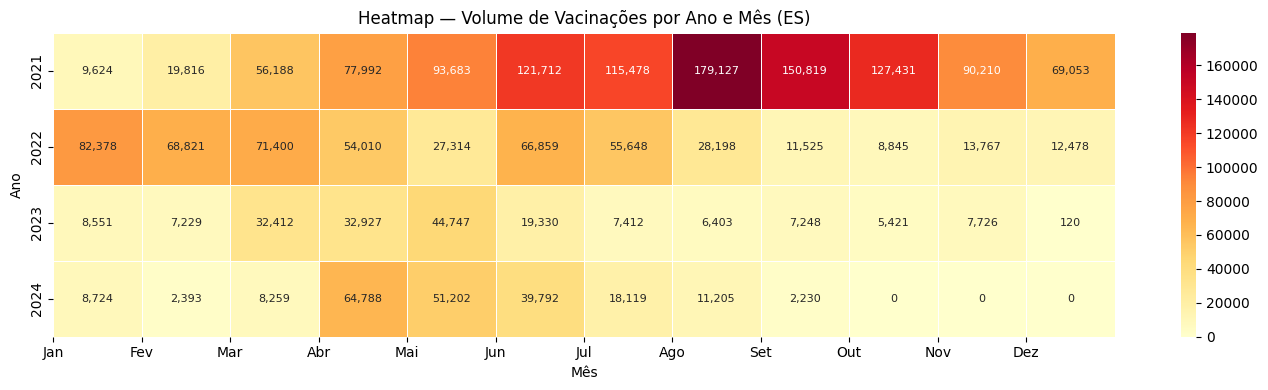

In [ ]:
pivot_mensal = (
    df_limpo
    .groupby(['ano_aplicacao', 'mes_aplicacao'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 4))
sns.heatmap(
    pivot_mensal,
    fmt=',',
    cmap='YlOrRd',
    linewidths=0.5,
    annot=True,
    annot_kws={'size': 8}
)
plt.title('Heatmap — Volume de Vacinações por Ano e Mês (ES)', fontsize=12)
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.xticks(ticks=range(12), labels=['Jan','Fev','Mar','Abr','Mai','Jun',
                                     'Jul','Ago','Set','Out','Nov','Dez'])
plt.tight_layout()
plt.show()

## 7. Conclusões

**Retomando a pergunta de pesquisa:** *Como se comportou a campanha de vacinação contra COVID-19 no ES ao longo do tempo? Existem perfis distintos de vacinados que reflitam a estratégia de priorização adotada?*

A resposta é sim para as duas perguntas.

O **clustering K-Means** identificou grupos bem definidos de vacinados. O cluster com maior idade média (≈61 anos) concentra registros dos primeiros meses da campanha — são os idosos e grupos prioritários que receberam as primeiras doses. À medida que o `mes_continuo` avança, a idade média cai progressivamente, refletindo a abertura gradual para adultos jovens e adolescentes. Isso é exatamente o que se esperava, e o fato de o algoritmo ter encontrado esses grupos sem nenhum rótulo prévio confirma que a campanha no ES seguiu fielmente a estratégia nacional de priorização por faixa de risco.

A **análise temporal com IQR** mostrou que a campanha teve um arco claro: crescimento acelerado no início de 2021, pico de intensidade entre meados de 2021 e início de 2022 (vacinação em massa da população adulta), e queda progressiva a partir de então. Os picos detectados como outliers provavelmente correspondem a mutirões ou ao primeiro dia de abertura de novos grupos — momentos em que a demanda reprimida se concentra num único dia. As quedas bruscas coincidem com o padrão esperado de feriados e finais de semana prolongados.

**Limitações:**
- O dataset usado é apenas a Parte 1 do ES. Há outras partes disponíveis no OpenDataSUS que ampliariam a análise.
- O clustering usou apenas duas features. Incluir município ou tipo de dose revelaria perfis mais ricos geograficamente.
- Os outliers temporais não foram validados com fontes externas (boletins da SESA-ES), então as causas ficam no campo da hipótese.

## 8. Exportação

In [ ]:
df_limpo.to_csv('dataset_covid_es_final.csv', index=False)
df_outlier[df_outlier['outlier']].to_csv('outliers_temporais.csv')
df_amostra[['paciente_idade','mes_continuo','cluster']].to_csv('perfil_clusters.csv', index=False)
print('Arquivos exportados com sucesso.')


Arquivos exportados com sucesso.
